## Importing the relevant packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2 
from math import sqrt
import seaborn as sns
sns.set()

## Importing the Data and Pre-processing 

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv") 
df_comp=raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.ffill()

In [3]:
df_comp['market_value']=df_comp.ftse

In [4]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

## The LLR Test

In [5]:
def LLR_test(mod_1, mod_2, DF = 1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))    
    p = chi2.sf(LR, DF).round(3)
    return p

## Creating Returns

In [ ]:
df['returns'] = df.market_value.pct_change(1)*100

In [11]:
df.returns

date
1994-01-07         NaN
1994-01-10   -0.156704
1994-01-11   -0.779229
1994-01-12   -1.222988
1994-01-13   -0.356166
                ...   
2013-04-01    0.000000
2013-04-02    1.230867
2013-04-03   -1.084327
2013-04-04   -1.186397
2013-04-05   -1.487049
Freq: B, Name: returns, Length: 5021, dtype: float64

## ACF for Returns

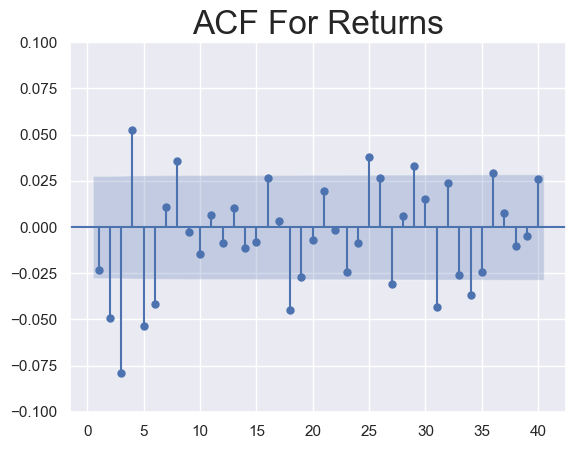

In [15]:
sgt.plot_acf(df.returns[1:],lags=40,zero=False)
plt.title("ACF For Returns",size=24)
plt.ylim(-.1,.1)
plt.show()

`When we fit Moving Average (MA) Models, we look for Stationarity in ACF Plots since we avoid past values in MA Model`                                           
`whereas if we try to fit AR Models, we look for lags we want to check in PACF Plots since we account for past values`

`Conclusion -> we should look for Fitting upto 8 lags since after that mostly the lags are insignificant`

## MA(1) for Returns

In [20]:
model_ma_1 = ARIMA(df.returns[1:], order=(0,0,1))
results_ma_1 = model_ma_1.fit()
print(results_ma_1.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -7929.595
Date:                Mon, 27 Apr 2026   AIC                          15865.190
Time:                        00:05:14   BIC                          15884.754
Sample:                    01-10-1994   HQIC                         15872.045
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.146      0.252      -0.013       0.051
ma.L1         -0.0257      0.009     -3.018      0.003      -0.042      -0.009
sigma2         1.3789      0.014     99.990      0.0

`First lag is nearly significant. Although we check for better models`                               

## Higher-Lag MA Models for Returns

In [22]:
# MA (2) Model
model_ma_2 = ARIMA(df.returns[1:], order=(0,0,2))
results_ma_2 = model_ma_2.fit()
print(results_ma_2.summary())
print(f"LLR value -> {LLR_test(model_ma_1,model_ma_2)}")

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -7922.864
Date:                Mon, 27 Apr 2026   AIC                          15853.728
Time:                        00:07:50   BIC                          15879.812
Sample:                    01-10-1994   HQIC                         15862.868
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.204      0.228      -0.012       0.049
ma.L1         -0.0327      0.009     -3.760      0.000      -0.050      -0.016
ma.L2         -0.0502      0.008     -6.416      0.0

`We see that the lags have become significant-> this corresponds to the ACF plot also`                                   
`Also LLR p value is <0.05 confirming the significance -> MA(2) > MA(1)`                                                   

In [23]:
model_ma_3 = ARIMA(df.returns[1:], order=(0,0,3))
results_ma_3 = model_ma_3.fit()
print(results_ma_3.summary())
print(f"LLR value -> {LLR_test(model_ma_2,model_ma_3)}")

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -7904.317
Date:                Mon, 27 Apr 2026   AIC                          15818.634
Time:                        00:09:25   BIC                          15851.240
Sample:                    01-10-1994   HQIC                         15830.060
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.296      0.195      -0.010       0.048
ma.L1         -0.0203      0.009     -2.334      0.020      -0.037      -0.003
ma.L2         -0.0556      0.008     -7.032      0.0

`Again MA(3) > MA(2)`

In [24]:
model_ma_4 = ARIMA(df.returns[1:], order=(0,0,4))
results_ma_4 = model_ma_4.fit()
print(results_ma_4.summary())
print(f"LLR value -> {LLR_test(model_ma_3,model_ma_4)}")

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 4)   Log Likelihood               -7898.773
Date:                Mon, 27 Apr 2026   AIC                          15809.547
Time:                        00:09:58   BIC                          15848.674
Sample:                    01-10-1994   HQIC                         15823.257
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.236      0.217      -0.011       0.049
ma.L1         -0.0203      0.009     -2.239      0.025      -0.038      -0.003
ma.L2         -0.0551      0.008     -6.835      0.0

`MA(4) > MA(3)`

In [25]:
model_ma_5 = ARIMA(df.returns[1:], order=(0,0,5))
results_ma_5 = model_ma_5.fit()
print(results_ma_5.summary())
print(f"LLR value -> {LLR_test(model_ma_4,model_ma_5)}")

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 5)   Log Likelihood               -7892.823
Date:                Mon, 27 Apr 2026   AIC                          15799.645
Time:                        00:10:25   BIC                          15845.294
Sample:                    01-10-1994   HQIC                         15815.641
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.282      0.200      -0.010       0.048
ma.L1         -0.0262      0.009     -2.839      0.005      -0.044      -0.008
ma.L2         -0.0497      0.008     -6.147      0.0

`MA(5) > MA(4)`

In [26]:
model_ma_6 = ARIMA(df.returns[1:], order=(0,0,6))
results_ma_6 = model_ma_6.fit()
print(results_ma_6.summary())
print(f"LLR value -> {LLR_test(model_ma_5,model_ma_6)}")

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 6)   Log Likelihood               -7889.221
Date:                Mon, 27 Apr 2026   AIC                          15794.442
Time:                        00:10:52   BIC                          15846.612
Sample:                    01-10-1994   HQIC                         15812.723
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.014      1.318      0.188      -0.009       0.047
ma.L1         -0.0237      0.009     -2.562      0.010      -0.042      -0.006
ma.L2         -0.0486      0.008     -5.982      0.0

`Still MA(6) > MA(5)`

In [27]:
model_ma_7 = ARIMA(df.returns[1:], order=(0,0,7))
results_ma_7 = model_ma_7.fit()
print(results_ma_7.summary())
print(f"LLR value -> {LLR_test(model_ma_6,model_ma_7)}")

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 7)   Log Likelihood               -7889.046
Date:                Mon, 27 Apr 2026   AIC                          15796.091
Time:                        00:11:09   BIC                          15854.782
Sample:                    01-10-1994   HQIC                         15816.657
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.303      0.193      -0.010       0.047
ma.L1         -0.0247      0.009     -2.645      0.008      -0.043      -0.006
ma.L2         -0.0488      0.008     -6.000      0.0

`OOPSIE Now we see that 7th lag value is insignificant, confirmed by LLR Test and ACF Plot`                                

`Confirming that MA(7) < MA(6) `                                                                         

`Should we then conclude that the best model we can have is MA(6)????`                                                  

`NOPE !!! we saw in the ACF Plot that 8th lag was significant, thus it is worth checking the fitting and LLR Result of MA(8) model in comparison to MA(7) and MA(6) Models !!!`

### Checking the results of MA(8) Model

In [28]:
model_ma_8 = ARIMA(df.returns[1:], order=(0,0,8))
results_ma_8 = model_ma_8.fit()
print(results_ma_8.summary())
print(f"LLR value -> {LLR_test(model_ma_7,model_ma_8)}")

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 8)   Log Likelihood               -7885.603
Date:                Mon, 27 Apr 2026   AIC                          15791.205
Time:                        00:14:47   BIC                          15856.417
Sample:                    01-10-1994   HQIC                         15814.056
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.253      0.210      -0.011       0.048
ma.L1         -0.0238      0.009     -2.527      0.011      -0.042      -0.005
ma.L2         -0.0495      0.008     -6.053      0.0

`Indeed as expected MA(8) performed better than MA(7) Model`

#### Let us check if it performs better than MA(6) as well or not?

In [29]:
print(f'LLR value -> {LLR_test(model_ma_6,model_ma_8,DF=2)}')

LLR value -> 0.027


`Since the LLR value is significant we can confirm that MA(8) is a better fit than MA(6) Model`                          
`Thus we can conclude that the best fit model for Returns is MA(8) Model`

## Residuals for Returns

`Let us compare the Residuals of MA(6) and MA(8) Models !!`

In [ ]:
# Residuals of MA(6) Model
df['res_ret_ma_8'] = results_ma_8.resid[1:] # we removed the first residual since current value shouldn't have residual

In [35]:
# Checking the Mean and variance of Residuals
print(df.res_ret_ma_8.mean()) # Almost zero
print(df.res_ret_ma_8.var()) # Nearly ~ 1.355

-1.662730828869874e-05
1.3555186081224004


In [50]:
3*np.sqrt(df.res_ret_ma_8.var())

np.float64(3.4928022379032004)

`Since the variance is ~1.355 and the data mimics gaussian white noise -> NormalDistribution`                              
`Thus the maximum values of ND can be obtained within -3 to +3 std i.e [-3.5, 3.5] so maximum off we can go is by 7% in our predictions, which is still very much `

In [40]:
df.head()

,market_value,returns,res_ret_ma_8
date,,,
1994-01-07,3445.98,NaN,NaN
1994-01-10,3440.58,-0.156704,NaN
1994-01-11,3413.77,-0.779229,-0.802107
1994-01-12,3372.02,-1.222988,-1.269464
1994-01-13,3360.01,-0.356166,-0.464783


In [39]:
# Let us check and confirm if the Residuals follow White Noise, we use Augmented Dickey-Fuller Test
sts.adfuller(df.res_ret_ma_8[2:])


(np.float64(-70.835371256093),
 0.0,
 0,
 5018,
 {'1%': np.float64(-3.4316538358533277),
  '5%': np.float64(-2.8621161549128313),
  '10%': np.float64(-2.567076687880585)},
 np.float64(15684.052217389388))

`We clearly see that p value is zero implies that all the residuals are Stationary and coefficients of ACF are zero`

`This mimics White Noise`

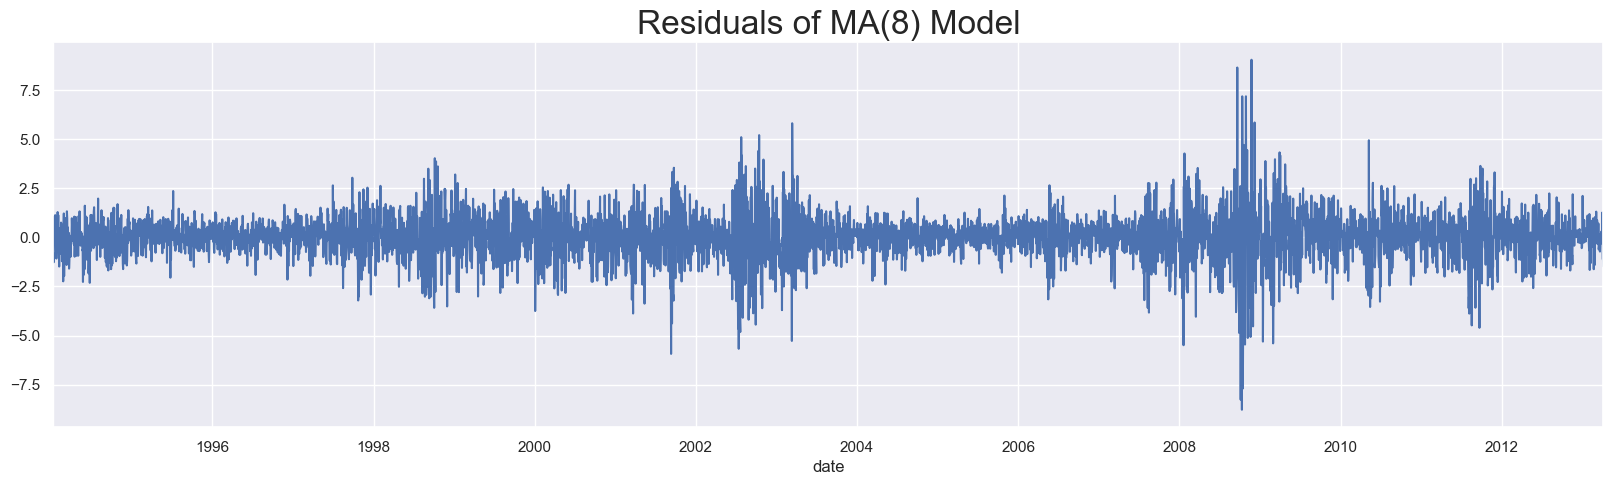

In [41]:
# Plotting the Residuals 
df.res_ret_ma_8[2:].plot(figsize=(20,5))
plt.title("Residuals of MA(8) Model",size=24)
plt.show()

#### Checking the Residuals of MA(6)

In [ ]:
df['res_ret_ma_6'] = results_ma_6.resid[1:]

In [43]:
df.head()

,market_value,returns,res_ret_ma_8,res_ret_ma_6
date,,,,
1994-01-07,3445.98,NaN,NaN,NaN
1994-01-10,3440.58,-0.156704,NaN,NaN
1994-01-11,3413.77,-0.779229,-0.802107,-0.802080
1994-01-12,3372.02,-1.222988,-1.269464,-1.268794
1994-01-13,3360.01,-0.356166,-0.464783,-0.461334


In [ ]:
# Checking the means and variance of MA(6) Residuals
print(df.res_ret_ma_6.mean()) # ~~ zero
print(df.res_ret_ma_6.var()) # ~1.357

-5.568362981693522e-06
1.3574757641808586


In [46]:
# Checking if this is Stationary and mimics White Noise
sts.adfuller(df.res_ret_ma_6[2:])

(np.float64(-70.83908082567434),
 0.0,
 0,
 5018,
 {'1%': np.float64(-3.4316538358533277),
  '5%': np.float64(-2.8621161549128313),
  '10%': np.float64(-2.567076687880585)},
 np.float64(15691.135334746092))

`Yes indeed the pvalue is zero so the residuals are Stationary and mimic White Noise`

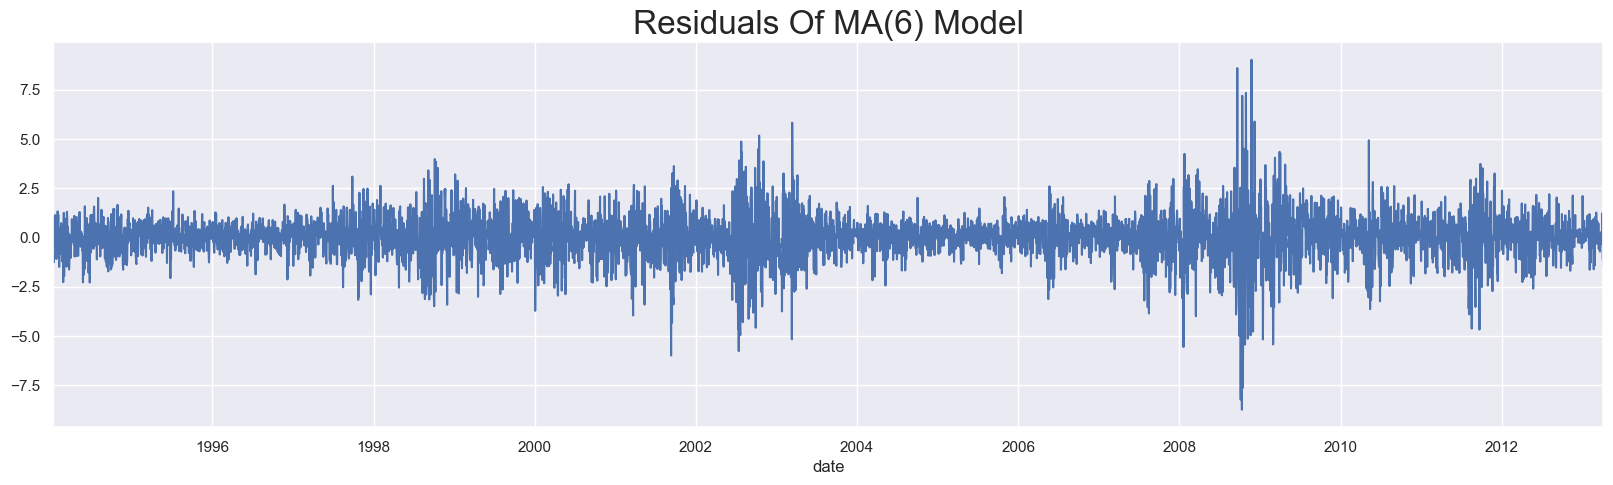

In [48]:
# Plot
df.res_ret_ma_6[2:].plot(figsize=(20,5))
plt.title("Residuals Of MA(6) Model",size=24)
plt.show()

`Conclusion ->`                                                                                                          
`MA(6) and MA(8) models are really close but since we saw in LLR Test MA(8) performs a bit better`

## Normalized Returns

## MA Models For Prices